# Import libraries

In [632]:
# 0. Import
import os
from re import search
from dfply import *
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from pathlib import Path

In [633]:
import celloracle as co
co.__version__

'0.8.0'

In [634]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

# Load settings

In [635]:
os.uname()[1]

'BI2404M'

In [636]:
if search("ricard", os.uname()[1]):
    exec(open('/Users/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/utils.py').read())
elif search("BI2404M", os.uname()[1]):
    exec(open('/Users/argelagr/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/argelagr/gastrulation_multiome_10x/utils.py').read())
elif search("ebi", os.uname()[1]):
    exec(open('/homes/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/utils.py').read())
elif search("Workstation", os.uname()[1]):
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/settings.py').read())
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/utils.py').read())
else:
    exit("Computer not recognised")

## Define I/O

In [637]:
io["outdir"] = Path(io["basedir"]) / "results/rna_atac/GRN/trajectories/blood_trajectory/"
io["outdir"]

PosixPath('/Users/argelagr/data/gastrulation_multiome_10x/results/rna_atac/GRN/trajectories/blood_trajectory')

In [638]:
# io['anndata'] = Path(io["basedir"]) / "results/rna_atac/rna_vs_acc/trajectories/blood_trajectory/anndata.h5ad"
io['anndata'] = Path(io["basedir"]) / "results/rna/trajectories/blood_trajectory/blood_adata.h5ad"
io['chip_GRN'] = Path(io["basedir"]) / 'results/rna_atac/GRN/chip_GRN.csv'
io['blood_chip_oracle'] = io['outdir'] / "ricard_blood_chip.celloracle.oracle"
io['blood_chip_links'] = io['outdir'] / 'ricard_blood_chip.celloracle.links'

## Define options 

scanpy options

In [639]:
# %%capture
# sc.settings.verbosity = 3
# sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(8, 7), facecolor='white')

In [640]:
opts["celltypes"] = [
   "Haematoendothelial_progenitors",
   "Blood_progenitors_1",
   "Blood_progenitors_2",
   "Erythroid1",
   "Erythroid2",
   "Erythroid3"
]

# 1. Prepare data



## 1.1. Load processed gene expression data (anndata)


In [641]:
io["anndata"]

PosixPath('/Users/argelagr/data/gastrulation_multiome_10x/results/rna/trajectories/blood_trajectory/blood_adata.h5ad')

In [642]:
# Load data. !!Replace the data path below when you use another data.
adata = sc.read_h5ad(io["anndata"])
adata

AnnData object with n_obs × n_vars = 3039 × 15965
    obs: 'sample', 'barcode', 'stage', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'pass_rnaQC', 'celltype.mapped', 'celltype.score', 'closest.cell', 'hybrid_score', 'doublet_call', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC', 'celltype.predicted'
    var: 'gene'
    uns: 'celltype.mapped_colors'

In [643]:
#adata.layers["raw_count"][:5,:5].todense()
# adata.X[:5,:5].todense()

In [644]:
adata.obs['trajectory'] = ['blood']*adata.n_obs

In [645]:
adata.uns['trajectory_colors'] = np.array(['#D33F6A'])

In [646]:
adata.layers["raw_count"] = adata.X.copy()

In [647]:
sc.pp.recipe_zheng17(adata, n_top_genes=3000, log=True, plot=False, copy=False)

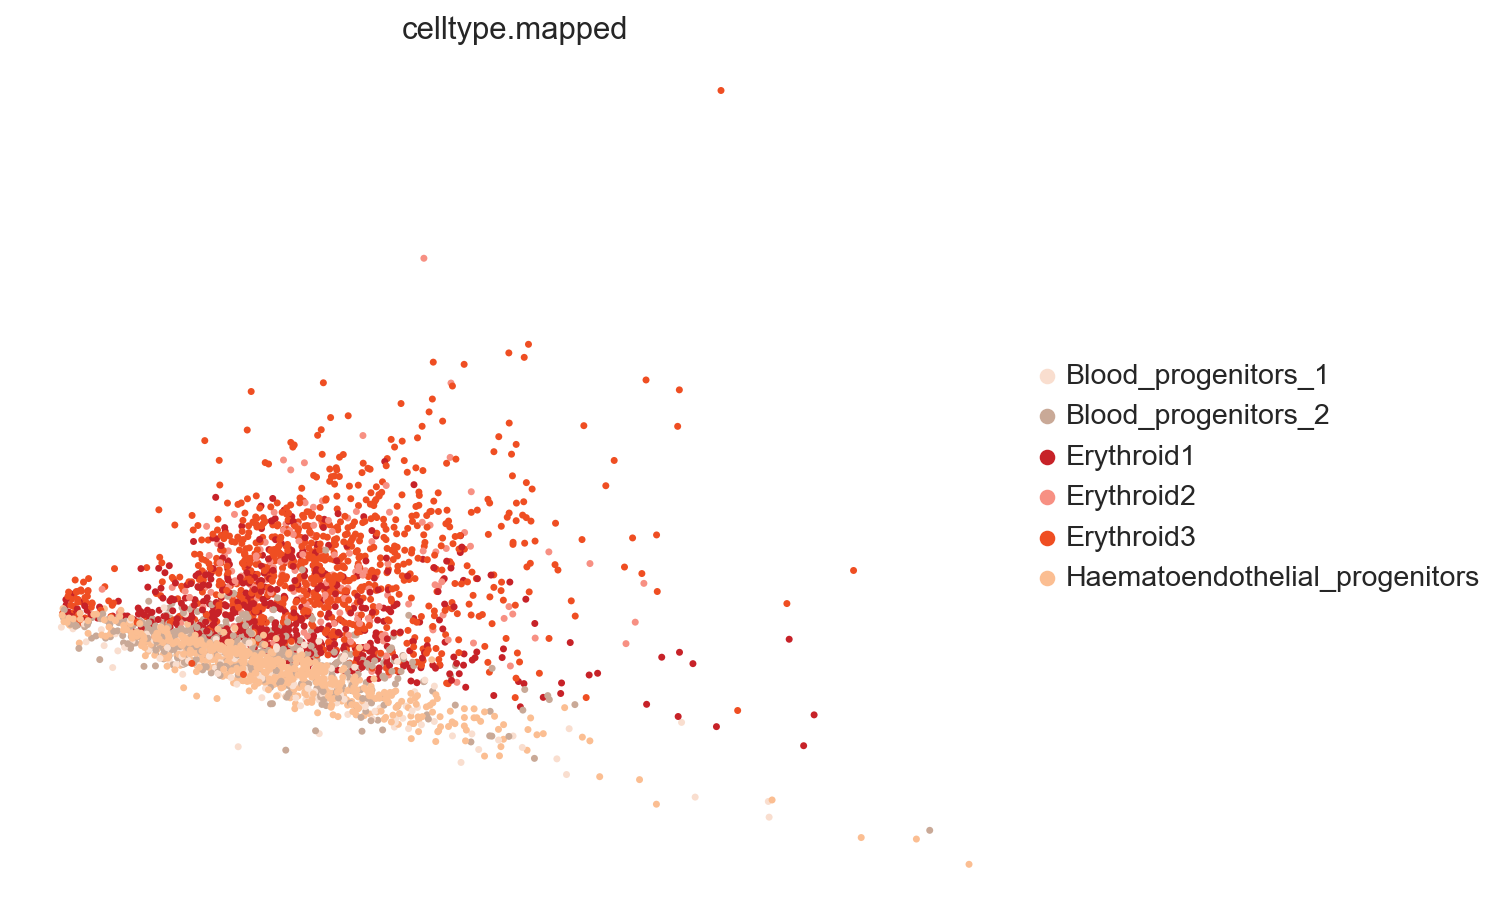

In [683]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca(adata, color="celltype.mapped", components=[1,2])

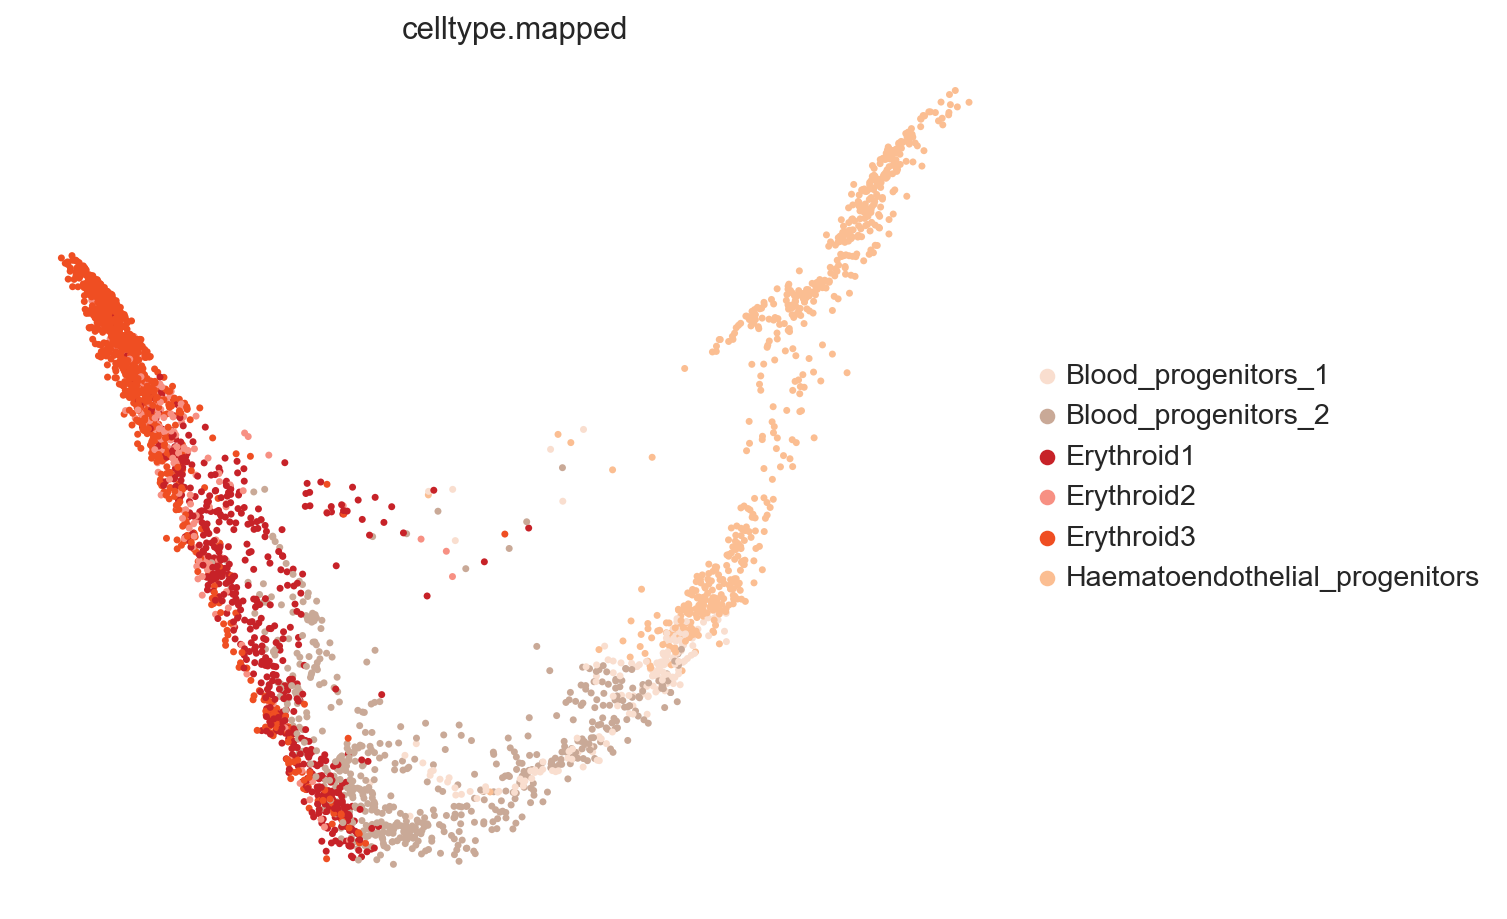

In [688]:
#sc.pp.neighbors(adata, n_neighbors=15, n_pcs=5)
#sc.tl.diffmap(adata, n_comps=3)
sc.pl.diffmap(adata,color=['celltype.mapped'], components=[1,2])

In [650]:
# We use raw mRNA count as an input of Oracle object.
adata.X = adata.layers["raw_count"].copy()

## 1.2. Load TF data. 
For the GRN inference, celloracle needs TF information, which contains lists of the regulatory candidate genes. 

In [651]:
#io['chip_GRN']

In [652]:
# TFinfo_df = pd.read_csv(io['chip_GRN'],header=0)
TFinfo_df2 = pd.read_csv("/Users/argelagr/data/gastrulation_multiome_10x/results/rna_atac/GRN/chip_GRN_ricard.csv",header=0).T
#TFinfo_df = pd.read_csv("/Users/argelagr/data/gastrulation_multiome_10x/results/rna_atac/GRN/chip_GRN_gavin.csv",header=0)

In [653]:
#TFinfo_df2.shape
#TFinfo_df2.iloc[:3,:3]
#TFinfo_df2.loc["Hba-x","KLF1"]

In [654]:
TFinfo_df2 = TFinfo_df2.reset_index().rename(columns={"index":"Target"})
TFinfo_df2[["peak_id"]] = np.zeros(TFinfo_df2.shape[0])
TFinfo_df2 = TFinfo_df2.rename(columns={'Target':'gene_short_name'})
TFinfo_df2.head()

,gene_short_name,Sox17,Klf7,Creb1,Fev,Pax3,Twist2,Gli2,Elk4,Sox13,...,Nfkb2,Tcf7l2,Emx2,Gata1,Elf4,Zic3,Sox3,Mecp2,Hdx,peak_id
0,Xkr4,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
1,Mrpl15,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
2,Lypla1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
3,Tcea1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
4,Rgs20,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0


In [655]:
#TFinfo_df.shape
#TFinfo_df.iloc[:3,:3]
#TFinfo_df2.loc["Hba-x","KLF1"]

In [656]:
TFinfo_df = TFinfo_df.rename(columns={'Unnamed: 0': 'peak_id','Target':'gene_short_name'})
TFinfo_df.head()

,peak_id,gene_short_name,Ahrr,Alx1,Alx3,Alx4,Ar,Arid2,Arid3a,Arid3b,...,Zfx,Zic1,Zic2,Zic3,Zic4,Zic5,Zkscan1,Zkscan3,Zkscan4,Zscan10
0,1,0610005C13Rik,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1110032A03Rik,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1110051M20Rik,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1600002K03Rik,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1700007K13Rik,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [657]:
TFinfo_df2.columns

Index(['gene_short_name', 'Sox17', 'Klf7', 'Creb1', 'Fev', 'Pax3', 'Twist2',
       'Gli2', 'Elk4', 'Sox13',
       ...
       'Nfkb2', 'Tcf7l2', 'Emx2', 'Gata1', 'Elf4', 'Zic3', 'Sox3', 'Mecp2',
       'Hdx', 'peak_id'],
      dtype='object', length=319)

In [658]:
#TFinfo_df_filt = TFinfo_df2.loc[:,["peak_id","gene_short_name","Klf1"]]
TFinfo_df_filt = TFinfo_df2 >> mask(X.gene_short_name.isin(adata.var.index))
TFinfo_df_filt

,gene_short_name,Sox17,Klf7,Creb1,Fev,Pax3,Twist2,Gli2,Elk4,Sox13,...,Nfkb2,Tcf7l2,Emx2,Gata1,Elf4,Zic3,Sox3,Mecp2,Hdx,peak_id
0,Xkr4,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
15,1700034P13Rik,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
16,Sgk3,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
19,Gm15818,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
24,Prex2,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15000,mt-Nd3,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
15001,mt-Nd4l,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
15002,mt-Nd4,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0
15003,mt-Nd5,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0.0


In [659]:
#tmp = TFinfo_df_filt.loc[:,["gene_short_name","Klf1"]] >> mask(X.Klf1>0)
#tmp[["gene_short_name"]].values
# TFinfo_df_filt[["Klf1"]].value_counts()
#"Mgst3"in tmp[["gene_short_name"]].values

In [660]:
# import importlib
# importlib.reload(co)

# 2. Initiate Oracle object

Celloracle has a custom called Oracle. We can use Oracle for the data preprocessing and GRN inference steps.
The Oracle object stores all of necessary information and does the calculations with its internal functions.
We instantiate an Oracle object, then input the gene expression data (anndata) and a TFinfo into the Oracle object.

In [661]:
oracle = co.Oracle()

## 2.1. load gene expression data into oracle object.

In [662]:
adata.var["symbol"] = adata.var.index.values
#adata.var["isin_top1000_var_mean_genes"] = True

In [663]:
oracle.import_anndata_as_raw_count(adata=adata,
                                   cluster_column_name="trajectory",
                                   embedding_name="X_diffmap")
# You can load TF info dataframe with the following code.


## 2.2. Load TFinfo into oracle object

In [664]:
# oracle.import_TF_data(TF_info_matrix=TFinfo_df)
oracle.import_TF_data(TF_info_matrix=TFinfo_df_filt)

In [665]:
oracle.adata.var.loc[:,["isin_TFdict_targets","isin_TFdict_regulators"]]
oracle.adata.var.loc[:,"isin_TFdict_regulators"].sum()
#oracle.adata.var.loc[:,"isin_TFdict_targets"].sum()

99

In [666]:
oracle.adata.var.loc[:,"isin_TFdict_targets"].sum()
oracle.adata.var.loc[:,"isin_TFdict_regulators"].sum()

99

# 3. Knn imputation
Celloracle uses almost the same strategy as velocyto for visualizing cell transitions. This process requires KNN imputation in advance.

For the KNN imputation, we need PCA and PC selection first.

## 3.1. PCA

20


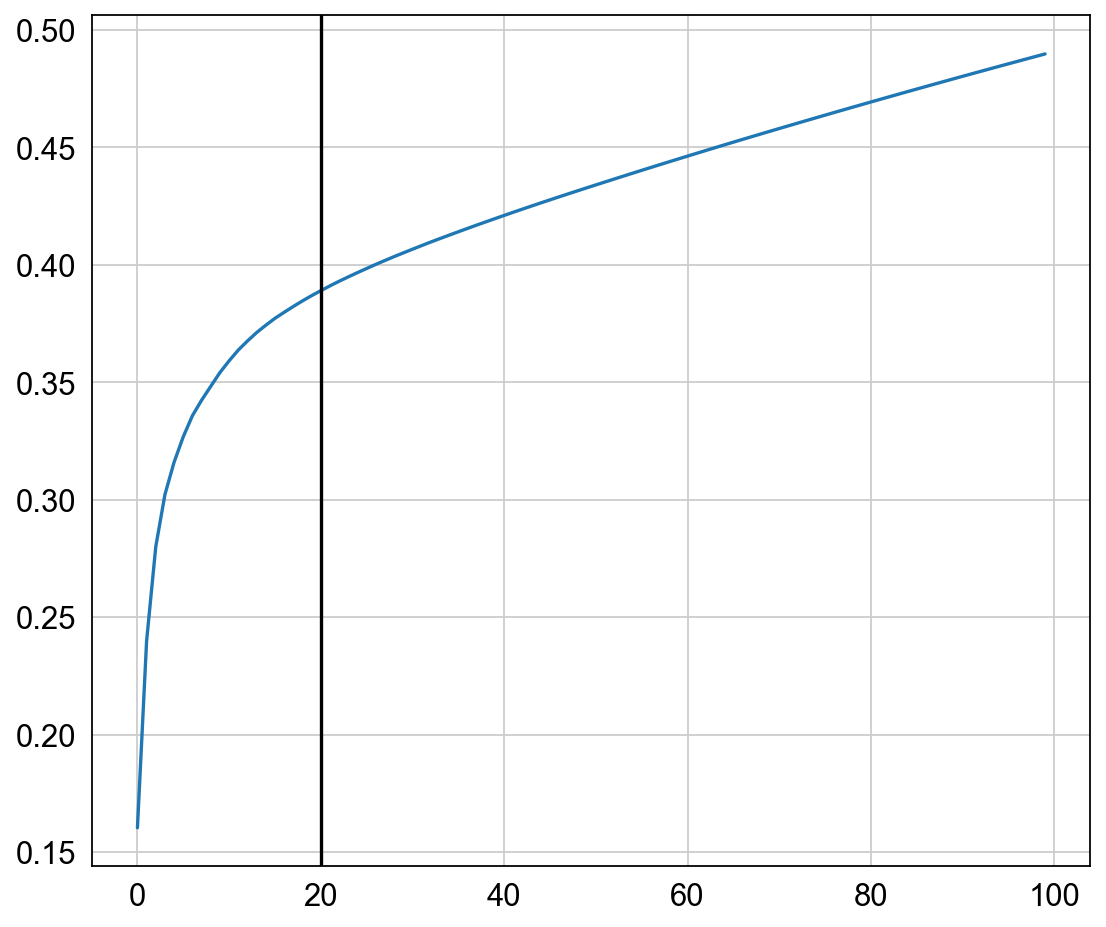

In [667]:
# Perform PCA
oracle.perform_PCA()

# Select important PCs
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
print(n_comps)
n_comps = min(n_comps, 50)

## 3.2. KNN imputation

       Nothing but it creates the attributes:
        knn: scipy.sparse.csr_matrix
            knn contiguity matrix
        knn_smoothing_w: scipy.sparse.lil_matrix
            the weights used for the smoothing
        Sx: np.ndarray
            smoothed spliced
        Ux: np.ndarray
            smoothed unspliced

In [668]:
k = 25

In [669]:
oracle.knn_imputation(n_pca_dims=1, k=k, balanced=True, b_sight=k*8, b_maxl=k*4, n_jobs=4)

In [670]:
oracle.knn.shape

(3039, 3039)

In [671]:
#oracle.adata.layers["normalized_count"]
oracle.adata.layers["imputed_count"].shape

(3039, 2999)

# 4. Save and Load.

Celloracle has some custom-classes: Links, Oracle and TFinfo.
You can save such an object using "to_hdf5".

Pleasae use "load_hdf5" function to load the file.


In [672]:
# Save oracle object.
io['blood_chip_oracle'] = io['outdir'] / "ricard_blood_chip_Klf1.celloracle.oracle"
oracle.to_hdf5(str(io['blood_chip_oracle']))

# 5. GRN calculation
The next step is constructing a cluster-specific GRN for all clusters.

You can calculate  GRNs with the "get_links" function, and the function returns GRNs as a Links object.
The Links object stores inferred GRNs and the corresponding metadata. You can do network analysis with the Links object.

The GRN will be calculated for each cluster/sub-group.
In the example below, we construct GRN for each unit of the "trajectory" clustering.

The GRNs can be calculated at any arbitrary unit as long as the clustering information is stored in anndata.

## 5.1. Get GRNs

In [673]:
links = oracle.get_links(cluster_name_for_GRN_unit="trajectory", alpha=10,
                        verbose_level=10, test_mode=False)
# Calculate GRN for each population in "GRN_unit" clustering unit.
# This step may take long time.

  0%|          | 0/1 [00:00<?, ?it/s]

inferring GRN for blood...


  0%|          | 0/2763 [00:00<?, ?it/s]

## 5.2. Export GRNs

Although celloracle has many functions for network analysis, you can analyze GRNs by hand if you choose.
The raw GRN data is stored in the attribute of "links_dict".

In [674]:
io['blood_chip_links'] = io['outdir'] / 'ricard_blood_chip_Klf1.celloracle.links'
links.to_hdf5(str(io['blood_chip_links']))

### Exploration

The TF-gene connections from celloracle are missing important connections. For example:
GATA1 -> (Zfpm1, Gypc, Hdgf, Epor)

In [675]:
links.filter_links(p=0.001, weight="coef_abs", thread_number=2000)

In [676]:
links.links_dict["blood"].shape
# links.links_dict["blood"] >> mask(X.source=="Klf1")
#links.cluster

(64405, 6)

In [677]:
links.links_dict["blood"] >> mask(X.source=="Gata1") >> arrange(X.p) >> head(n=15)

,source,target,coef_mean,coef_abs,p,-logp
36367,Gata1,Mbnl1,0.191993,0.191993,3.193980e-23,22.495668
11196,Gata1,Cenpp,0.189622,0.189622,1.448168e-21,20.839181
58509,Gata1,Tmcc2,0.055070,0.055070,3.467004e-20,19.460046
50121,Gata1,Rps11,0.119839,0.119839,1.836356e-19,18.736043
4560,Gata1,Ank,0.072118,0.072118,1.894957e-19,18.722401
51967,Gata1,Serac1,0.024995,0.024995,1.784521e-18,17.748478
19209,Gata1,Fam117a,0.080646,0.080646,3.438056e-18,17.463687
45507,Gata1,Ppm1d,0.066848,0.066848,6.526452e-18,17.185323
29410,Gata1,Hipk2,0.217350,0.217350,1.723600e-17,16.763563
50911,Gata1,Runx1t1,0.055619,0.055619,3.206636e-17,16.493950


In [ ]:
links.filtered_links["blood"] >> mask(X.source=="Klf1")

In [ ]:
links.get_network_entropy()
links.entropy.head()

In [ ]:
links.plot_degree_distributions()

In [ ]:
links.get_score()

In [ ]:
links.plot_cartography_scatter_per_cluster()

In [678]:
oracle.embedding

array([[-0.017859433 ,  0.01980075  , -0.012578837 ],
       [-0.018328762 ,  0.026005853 ,  0.000460077 ],
       [-0.017920084 ,  0.0065102796, -0.026446406 ],
       ...,
       [-0.018753964 ,  0.035871584 ,  0.032563087 ],
       [-0.018409835 ,  0.025440253 ,  0.01882668  ],
       [-0.017543744 , -0.014812126 ,  0.0077477987]], dtype=float32)

In [681]:
adata.obsm["X_diffmap"].shape

(3039, 3)